#### 1. Vad kännetecknar regressionsproblem? Ge några exempel på tillämpnings-områden.
Regressionsproblem kännetecknas av att målvariabeln är kontinuerlig — svaret är ett tal på en skala, inte en kategori. Avstånd mellan värden är meningsfulla, och modellen kan därför ha "nästan rätt".

Det gör att utvärderingsmåtten mäter avstånd (RMSE, MSE, MAE) istället för att räkna träffar som i klassificering.

Exempel: huspriser, löneprognoser, bränsleeffektivitet, efterfrågeprognoser, energiförbrukning, leveranstider, sjukdomsprogression, försäkringspremier.

#### 2. Förklara utvärderingsmåtten RMSE, MSE och MAE.
Alla tre mäter genomsnittligt fel vid regression. MSE, Straffar stora fel hårt. Fel enhet (kvadrerad). RMSE, Samma som MSE men i rätt enhet — tolkbart. MAE, Alla fel väger proportionerligt. Robust mot outliers

#### 3. Om vi ska rangordna olika modeller, spelar det någon roll om RMSE eller MSE används? Varför?
Nej, rangordningen blir identisk. RMSE är roten ur MSE, och kvadratroten är monotont växande för icke-negativa tal — den bevarar alltså ordningen. Har modell A lägre MSE än modell B har den också lägre RMSE.

#### 4. Förklara mycket översiktligt vad gradient descent är.
Gradient descent är en optimeringsmetod som stegvis justerar modellens parametrar för att minimera felet.

T.ex om du står i dimma i ett kulligt landskap och ska hitta lägsta punkten. Du känner lutningen under fötterna, tar ett steg nedåt, känner efter igen, upprepar.

#### 5. Vad är the bias variance trade-off ? Varför är mer komplexa modeller inte alltid bättre?
Modellens totala fel består av tre delar:

Bias — fel av för enkla antaganden. En rak linje kan inte följa ett kurvigt samband. Ger underfitting: dåligt överallt.
Varians — fel av för stor känslighet för exakt vilken träningsdata modellen fick. Ger overfitting: bra på träning, dåligt på ny data.
Irreducibelt fel — slumpen i datan själv. Går inte att komma åt.

Trade-offen: enklare modell - lägre varians men högre bias. Mer komplex modell - lägre bias men högre varians. Totalfelet bildar en U-kurva och målet är att hamna i botten.

Varför komplexare inte alltid är bättre:

- överanpassar lättare — kapacitet att fånga mönster är också kapacitet att fånga brus. 
- kräver mer data för att skilja mönster från slump
- sambandet kan faktiskt vara enkelt
- kostar mer i tid och minne
- tappar tolkbarhet

#### 6. Några vanligt förekommande modeller för regressionsproblem är enligt nedan. Förklara översiktligt hur respektive modell fungerar. Läs även igenom respektive modells dokumentation, notera att du inte behöver förstå alla detaljer från dokumentationen men det är bra att ha läst igenom den.
- a) Linjär regression - anpassar en rät linje genom datan genom att minimera summan av kvadrerade fel. Koefficienterna är direkt tolkbara — hur mycket y ändras per steg i x. Snabb, enkel, helt genomskinlig. Klarar bara linjära samband och är känslig för outliers.
- b) Ridge regression - linjär regression plus ett straff för stora koefficienter (L2, summan av kvadraterna). Håller koefficienterna små, vilket minskar varians och motverkar overfitting. alpha styr straffets styrka. Bra vid korrelerade variabler. Kräver skalning. Krymper koefficienter mot noll men aldrig till noll.
- c) Lasso regression - linjär regression plus straff på summan av koefficienternas absolutbelopp (L1). Skillnaden mot ridge är att lasso kan sätta koefficienter till exakt noll, vilket ger automatisk variabelselektion — oviktiga variabler faller ur modellen. Praktiskt vid många variabler. Vid korrelerade variabler väljer den dock ofta godtyckligt en och nollar resten.
- d) Elastic net- kombinerar ridge och lasso — båda straffen samtidigt. alpha styr total styrka, l1_ratio styr blandningen (1 = ren lasso, 0 = ren ridge). Ger lassos variabelselektion men hanterar korrelerade variabler bättre, genom att behålla eller nolla dem som grupp. Ofta ett tryggt val, till priset av en extra hyperparameter.
- e) Support vector machines- lägger ett rör med bredden epsilon runt prediktionslinjen. Punkter innanför räknas som rätt och ignoreras; bara punkterna utanför (stödvektorerna) formar modellen. Gör den robust mot brus.
- f) Beslutsträd - delar upp datan genom en serie ja/nej-frågor på variablerna. Varje löv innehåller en grupp observationer, och prediktionen är medelvärdet av y i den gruppen. Algoritmen väljer vid varje steg den delning som minskar felet mest.
- g) Ensemble learning - grundidén är att många modeller tillsammans slår en ensam, eftersom deras fel tar ut varandra. Förutsättningen är att modellerna gör olika fel.
- h) Random forest - bagging av beslutsträd plus en extra slumpmekanism — vid varje delning får trädet bara välja bland ett slumpmässigt urval av variablerna (max_features).

#### 7. White box och black box
- White box = modellens inre logik är synlig och begriplig. Linjär regression (koefficienterna är modellen) och små beslutsträd (går att rita och följa). Du kan säga exakt varför en prediktion blev som den blev.

- Black box = modellen fungerar men kedjan från indata till svar går inte att följa. Random forest med hundratals träd, SVM med rbf-kernel, neurala nätverk. Inget är hemligt — komplexiteten gör det bara obegripligt för en människa.

#### 8. Vad är skillnaden mellan bagging och pasting?
Båda tränar många instanser av samma modell på olika slumpmässiga urval av träningsdatan. Skillnaden är återläggningen:

- Bagging drar med återläggning — samma rad kan förekomma flera gånger i ett urval, andra rader inte alls. Cirka 63 % unika rader per urval; resten blir out-of-bag och kan användas för gratis utvärdering.
- Pasting drar utan återläggning — varje rad högst en gång per urval.

#### 9. Förklara hur man kan tolka figur 3.1 på sidan 113.

Figuren visar enkel linjär regression. De svarta punkterna är observerad data 
och den blå linjen modellens prediktioner, med intercept θ₀ och lutning θ₁. 
De röda vertikala linjerna är residualerna — skillnaden mellan verkligt och 
predikterat värde — och modellen väljer den linje som minimerar summan av 
residualerna i kvadrat.

#### 10. Förklara hur man kan tolka figur 3.13 på sidan 140. Hur hänger den ihop med figur 3.14 på sidan 141?
Figur 3.13 visar ett beslutsträd som trädstruktur: varje nod har en fråga, antal observationer och ett value som är medelvärdet av y i noden.
Figur 3.14 visar samma modell i X1-X2-planet, där trädets tröskelvärden blivit linjer som delar planet i fyra rutor — en per lövnod. Alla punkter i samma ruta får samma prediktion, vilket visar att beslutsträd ger trappstegsformade prediktioner med axelparallella gränser.

#### 11. Vi har lärt oss utvärderingsmåtten RMSE, MSE och MAE. Ett annat utvärderingsmått är det som benämns för determinationskoeﬀicienten eller 𝑅2. Förklara vad det är för mått. Du kan läsa dokumentationen om det på nedanstående två länkar.
R² mäter hur stor andel av variationen i y som modellen förklarar.
R² = 1 är perfekt, R² = 0 betyder att modellen inte är bättre än att alltid gissa medelvärdet, och negativa värden betyder att den är sämre än så. Till skillnad från RMSE är måttet enhetslöst, vilket gör det lätt att jämföra mellan olika problem.

#### 13. EDA — hr_employee_data.xlsx

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

In [2]:
hr = pd.read_excel("../data/hr_employee_data.xlsx")
print(hr.shape)
print(hr.isna().sum().sum(), "saknade värden")
hr.head()

(14999, 11)
0 saknade värden


,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
hr.info()
hr.describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  str    
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  str    
 10  salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(3)
memory usage: 1.3 MB


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.00,14999.00,14999.00,14999.00,14999.00,14999.00,14999.00,14999.00
mean,0.61,0.72,3.80,201.05,3.50,0.14,0.24,0.02
std,0.25,0.17,1.23,49.94,1.46,0.35,0.43,0.14
min,0.09,0.36,2.00,96.00,2.00,0.00,0.00,0.00
25%,0.44,0.56,3.00,156.00,3.00,0.00,0.00,0.00
50%,0.64,0.72,4.00,200.00,3.00,0.00,0.00,0.00
75%,0.82,0.87,5.00,245.00,4.00,0.00,0.00,0.00
max,1.00,1.00,7.00,310.00,10.00,1.00,1.00,1.00


In [4]:
print(hr["left"].value_counts())
print(f"Andel som slutat: {hr['left'].mean():.1%}")

left
0    11428
1     3571
Name: count, dtype: int64
Andel som slutat: 23.8%


In [5]:
num_cols = hr.select_dtypes("number").columns.drop("left")
hr.groupby("left")[num_cols].mean().round(2).T

left,0,1
satisfaction_level,0.67,0.44
last_evaluation,0.72,0.72
number_project,3.79,3.86
average_montly_hours,199.06,207.42
time_spend_company,3.38,3.88
Work_accident,0.18,0.05
promotion_last_5years,0.03,0.01


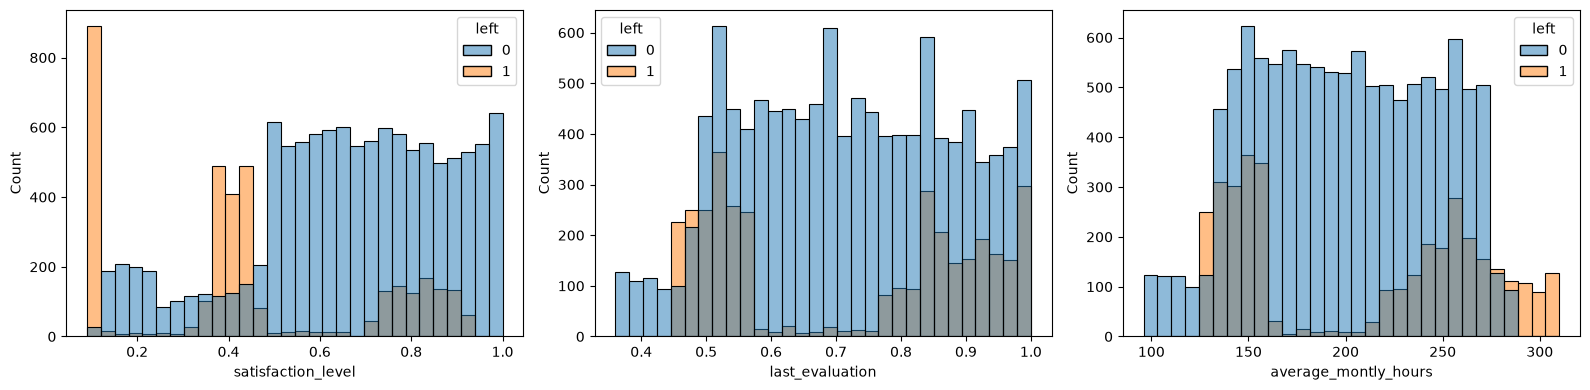

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(data=hr, x="satisfaction_level", hue="left", bins=30, ax=axs[0])
sns.histplot(data=hr, x="last_evaluation", hue="left", bins=30, ax=axs[1])
sns.histplot(data=hr, x="average_montly_hours", hue="left", bins=30, ax=axs[2])
plt.tight_layout()
plt.show()

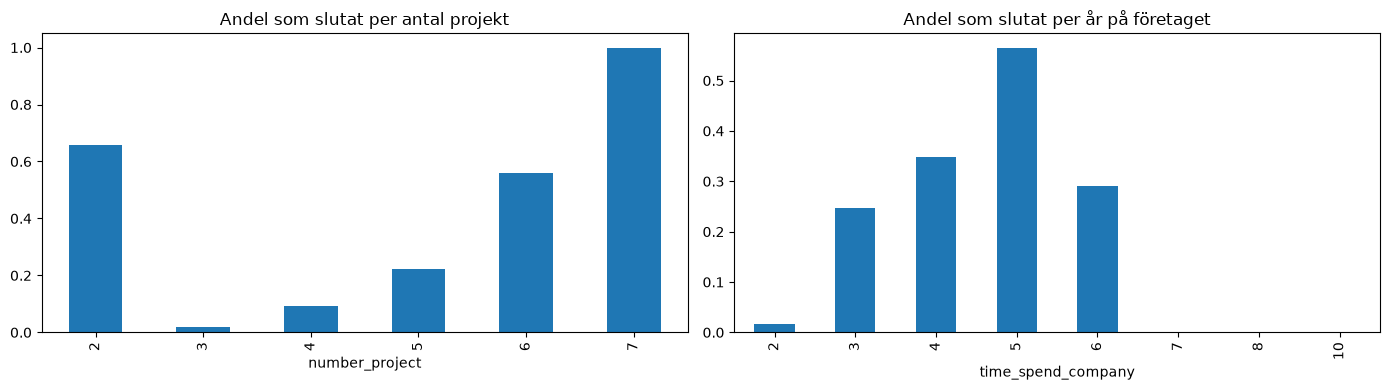

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
hr.groupby("number_project")["left"].mean().plot(
    kind="bar", ax=axs[0], title="Andel som slutat per antal projekt")
hr.groupby("time_spend_company")["left"].mean().plot(
    kind="bar", ax=axs[1], title="Andel som slutat per år på företaget")
plt.tight_layout()
plt.show()

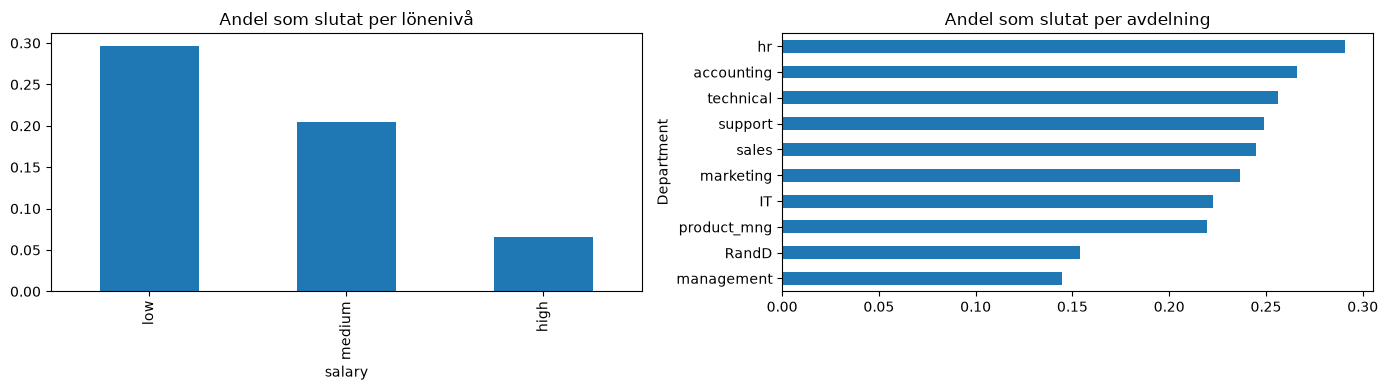

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
hr.groupby("salary")["left"].mean().reindex(["low", "medium", "high"]).plot(
    kind="bar", ax=axs[0], title="Andel som slutat per lönenivå")
hr.groupby("Department")["left"].mean().sort_values().plot(
    kind="barh", ax=axs[1], title="Andel som slutat per avdelning")
plt.tight_layout()
plt.show()

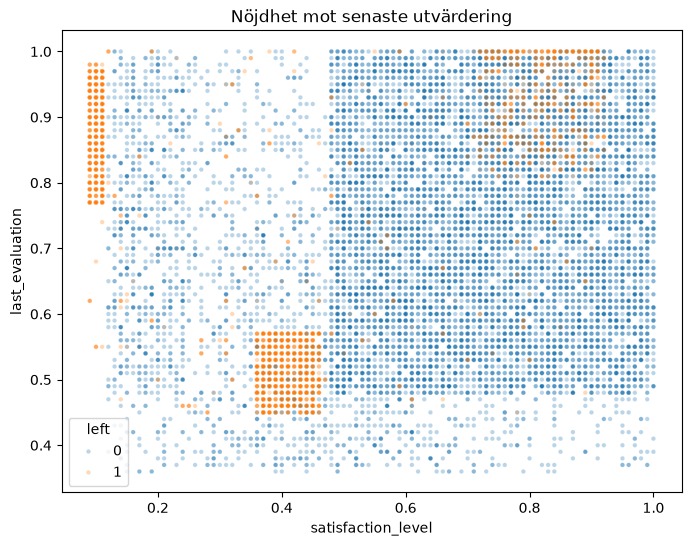

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=hr, x="satisfaction_level", y="last_evaluation",
                hue="left", alpha=0.3, s=10)
plt.title("Nöjdhet mot senaste utvärdering")
plt.show()

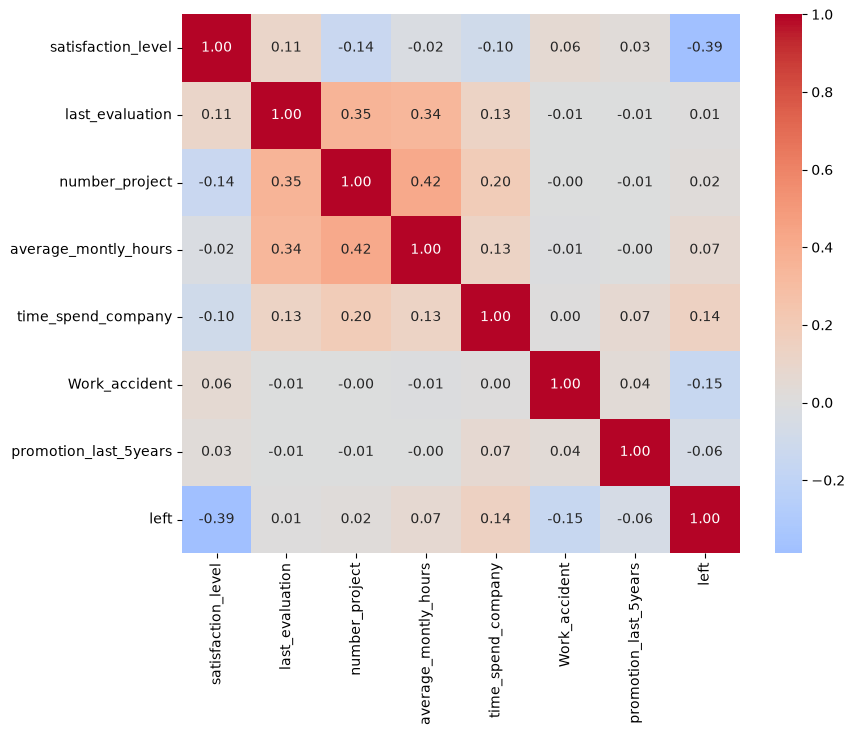

In [10]:
plt.figure(figsize=(9, 7))
sns.heatmap(hr[num_cols.tolist() + ["left"]].corr(),
            annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

Datan innehåller 14 999 anställda utan saknade värden. 23,8 % har slutat.

**Nöjdhet är den tydligaste signalen.** De som slutat har i snitt 0,44 i nöjdhet 
mot 0,67 för de som stannat. Det är också den variabel som korrelerar starkast 
med att sluta.

**Spridningsdiagrammet visar tre grupper av avhoppare:**
- låg nöjdhet men hög utvärdering — högpresterande som är missnöjda, troligen utbrända
- medelmåttig nöjdhet och låg utvärdering — lågpresterande
- hög nöjdhet och hög utvärdering — toppresterare som ändå går

**Arbetsbelastningen ger ett U-mönster.** Med 2 projekt har 66 % slutat, med 3 
projekt bara 2 %. Sedan stiger det igen: 56 % vid 6 projekt och 100 % vid 7. 
Både för lite och för mycket arbete driver folk att sluta.

**Anställningstid:** avhoppen ökar fram till år 5 (57 %) och upphör nästan helt 
efter år 6. År 3–5 är den kritiska perioden.

**Lön:** 30 % av de med låg lön har slutat, mot 20 % med medellön och 7 % med hög.

**Befordran:** 24 % av de som inte befordrats har slutat, mot 6 % av de befordrade.

**Avdelning:** HR (29 %) och accounting (27 %) högst, management (14 %) och 
R&D (15 %) lägst.

**Rekommendationer:** följ upp nöjdhet regelbundet, se över arbetsfördelningen så 
att ingen har för få eller för många projekt, var uppmärksam på anställda under 
år 3–5, och se över lön och befordringsvägar för högpresterande.

Analysen visar samband, inte orsaker. Datan innehåller också cirka 3 000 rader 
som är identiska i allt utom Emp_Id, vilket kan vara värt att undersöka.

#### 16. Komplett ML-flöde — diamonds.csv

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

dia = pd.read_csv("../data/diamonds.csv").drop(columns="Unnamed: 0")
print(dia.shape)
print(dia.isna().sum().sum(), "saknade värden")
dia.head()

(53940, 10)
0 saknade värden


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [12]:
dia.describe().round(2)

,carat,depth,table,price,x,y,z
count,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00
mean,0.80,61.75,57.46,3932.80,5.73,5.73,3.54
std,0.47,1.43,2.23,3989.44,1.12,1.14,0.71
min,0.20,43.00,43.00,326.00,0.00,0.00,0.00
25%,0.40,61.00,56.00,950.00,4.71,4.72,2.91
50%,0.70,61.80,57.00,2401.00,5.70,5.71,3.53
75%,1.04,62.50,59.00,5324.25,6.54,6.54,4.04
max,5.01,79.00,95.00,18823.00,10.74,58.90,31.80


In [13]:
print("Rader med x, y eller z = 0:", (dia[["x", "y", "z"]] == 0).any(axis=1).sum())
dia = dia[(dia[["x", "y", "z"]] > 0).all(axis=1)]
print(dia.shape)

Rader med x, y eller z = 0: 20
(53920, 10)


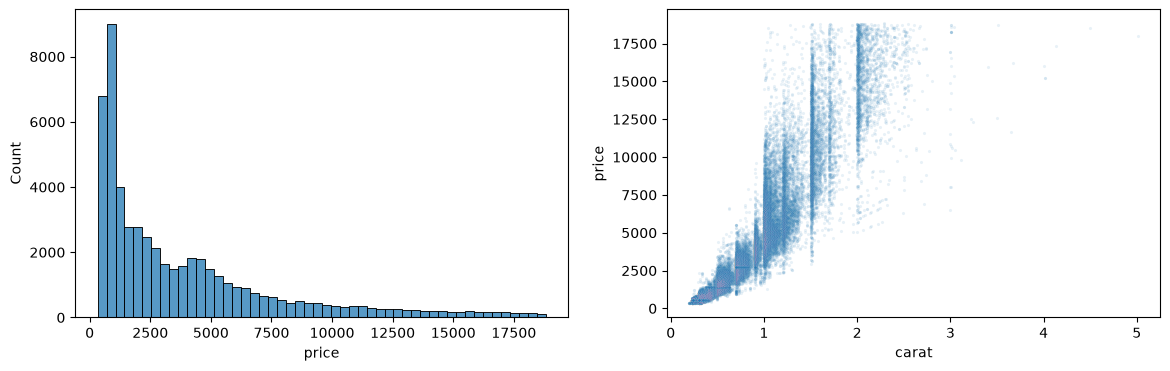

price    1.000
carat    0.922
x        0.887
z        0.868
y        0.868
table    0.127
depth   -0.011
Name: price, dtype: float64

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(dia["price"], bins=50, ax=axs[0])
sns.scatterplot(data=dia, x="carat", y="price", alpha=0.1, s=5, ax=axs[1])
plt.show()

dia.corr(numeric_only=True)["price"].sort_values(ascending=False).round(3)

In [15]:
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
color_order = ["J", "I", "H", "G", "F", "E", "D"]
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

dia["cut"] = dia["cut"].map({k: i for i, k in enumerate(cut_order)})
dia["color"] = dia["color"].map({k: i for i, k in enumerate(color_order)})
dia["clarity"] = dia["clarity"].map({k: i for i, k in enumerate(clarity_order)})

dia.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,4,5,1,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,5,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,5,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,1,3,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,0,1,63.3,58.0,335,4.34,4.35,2.75


In [16]:
X = dia.drop(columns="price")
y = dia["price"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42)

print(len(X_train), len(X_val), len(X_test))

32352 10784 10784


In [17]:
models = {
    "Linjär regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    print(f"{name}: RMSE {root_mean_squared_error(y_val, pred):.0f}, "
          f"R² {r2_score(y_val, pred):.3f}")

Linjär regression: RMSE 1257, R² 0.900
Random Forest: RMSE 571, R² 0.979


Random Forest presterar klart bättre: RMSE 571 mot 1257 och R² 0,98 mot 0,90. 
Linjär regression kan inte fånga att priset växer snabbare än linjärt med 
storleken. Random Forest väljs.

In [18]:
final_model = RandomForestRegressor(n_estimators=100, random_state=42)
final_model.fit(X_train_full, y_train_full)

pred_test = final_model.predict(X_test)
rmse_test = root_mean_squared_error(y_test, pred_test)

print(f"Test RMSE: {rmse_test:.0f}")
print(f"Test R²:   {r2_score(y_test, pred_test):.3f}")
print(f"RMSE i förhållande till medelpris: {rmse_test / y_test.mean():.1%}")

Test RMSE: 514
Test R²:   0.984
RMSE i förhållande till medelpris: 13.0%


In [19]:
importances = pd.Series(final_model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False).round(3).to_string())

carat      0.568
y          0.318
clarity    0.063
color      0.032
x          0.006
z          0.005
depth      0.003
table      0.002
cut        0.002


På testdatan ger modellen RMSE 514 och R² 0,98. Med ett medelpris på cirka 
3 950 motsvarar felet ungefär 13 %.

Feature importance visar att storleken dominerar: carat (0,57) och y (0,32) 
står tillsammans för nästan 90 %. Därefter kommer clarity och color. Cut har 
nästan ingen betydelse när storlek, färg och klarhet redan är kända.

Möjliga förbättringar: hyperparameterjustering med GridSearchCV, eller att ta 
bort x, y och z eftersom de mäter ungefär samma sak som carat.